#**ACTIVIDAD ALGORITMOS DE CLASIFICACIÓN**

La empresa DataVision te ha contratado como analista de datos para desarrollar un modelo de
clasificación de clientes. Se te ha proporcionado un conjunto de datos con información sobre
clientes, incluyendo variables como edad, ingresos, historial de compras y suscripciones.
Tu tarea es aplicar distintos algoritmos de clasificación para predecir si un cliente potencial
contratará un nuevo servicio.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta_archivos = '/content/drive/MyDrive/bootcamp ciencia de datos/evaluaciones/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score,  classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

##**Exploración inicial**

**1. Carga de datos (1 punto)**
- Descarga el archivo clientes.csv.
- Carga el conjunto de datos utilizando Python y realiza una exploración inicial.

In [ ]:
df = pd.read_csv(ruta_archivos + 'clientes.csv')

print('shape', df.shape)
df.head()

shape (500, 5)


,Edad,Ingresos,Historial_Compras,Suscripcion_Actual,Contratara_Servicio
0,56,19000,32,0,0
1,46,85588,22,0,0
2,32,53304,14,1,0
3,60,84449,32,0,0
4,25,97986,24,0,0


In [ ]:
atributos = df.columns.drop('Contratara_Servicio').tolist()
target = 'Contratara_Servicio'
print(f'atributos: {atributos}')

atributos: ['Edad', 'Ingresos', 'Historial_Compras', 'Suscripcion_Actual']


In [ ]:
# revisar duplicados
print(f'Cantidad de duplicados: {df.duplicated().sum()}')

# revisar nulos
print(f'Cantidad de nulos: {df.isnull().sum().sum()}')

Cantidad de duplicados: 0
Cantidad de nulos: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Edad                 500 non-null    int64
 1   Ingresos             500 non-null    int64
 2   Historial_Compras    500 non-null    int64
 3   Suscripcion_Actual   500 non-null    int64
 4   Contratara_Servicio  500 non-null    int64
dtypes: int64(5)
memory usage: 19.7 KB


In [ ]:
df.describe()

,Edad,Ingresos,Historial_Compras,Suscripcion_Actual,Contratara_Servicio
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,41.278000,55438.236000,25.384000,0.304000,0.106000
std,13.389072,25143.335891,14.045323,0.460443,0.308146
min,18.000000,15055.000000,0.000000,0.000000,0.000000
25%,30.000000,34250.500000,14.000000,0.000000,0.000000
50%,42.000000,53578.000000,26.000000,0.000000,0.000000
75%,52.000000,76554.000000,37.000000,1.000000,0.000000
max,64.000000,99791.000000,49.000000,1.000000,1.000000


La mediana es similar a la media para los atributos edad, ingresos e historial de compras.

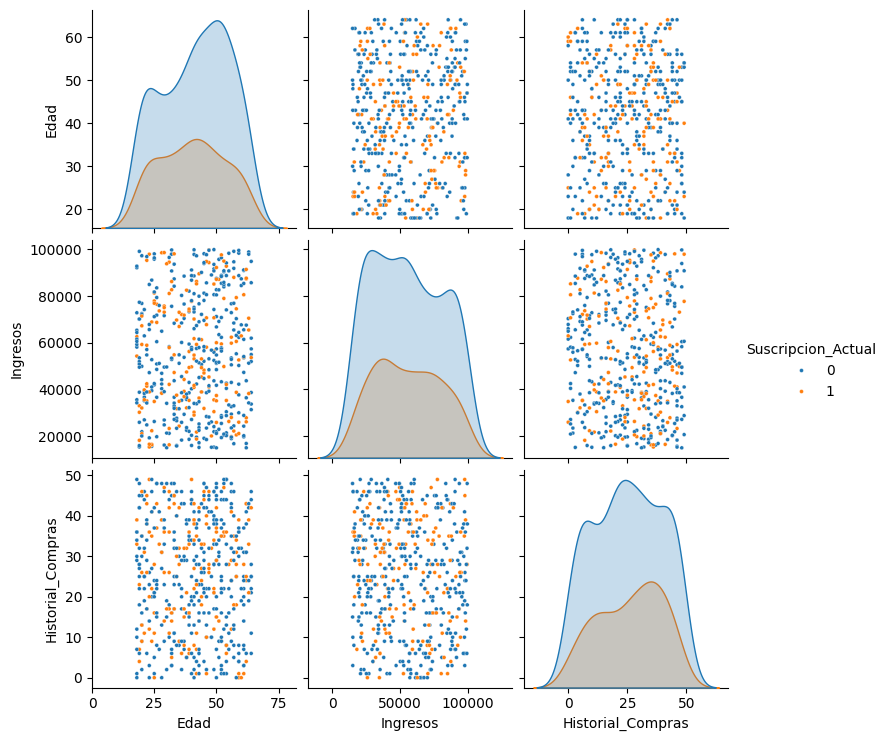

In [ ]:
sns.pairplot(df[atributos], diag_kind='kde', hue='Suscripcion_Actual',  plot_kws={'s':8})
plt.show()

No es posible asignar pertenencia a rango etario, nivel de ingresos e historial de compras para los cientes con suscripción actual.

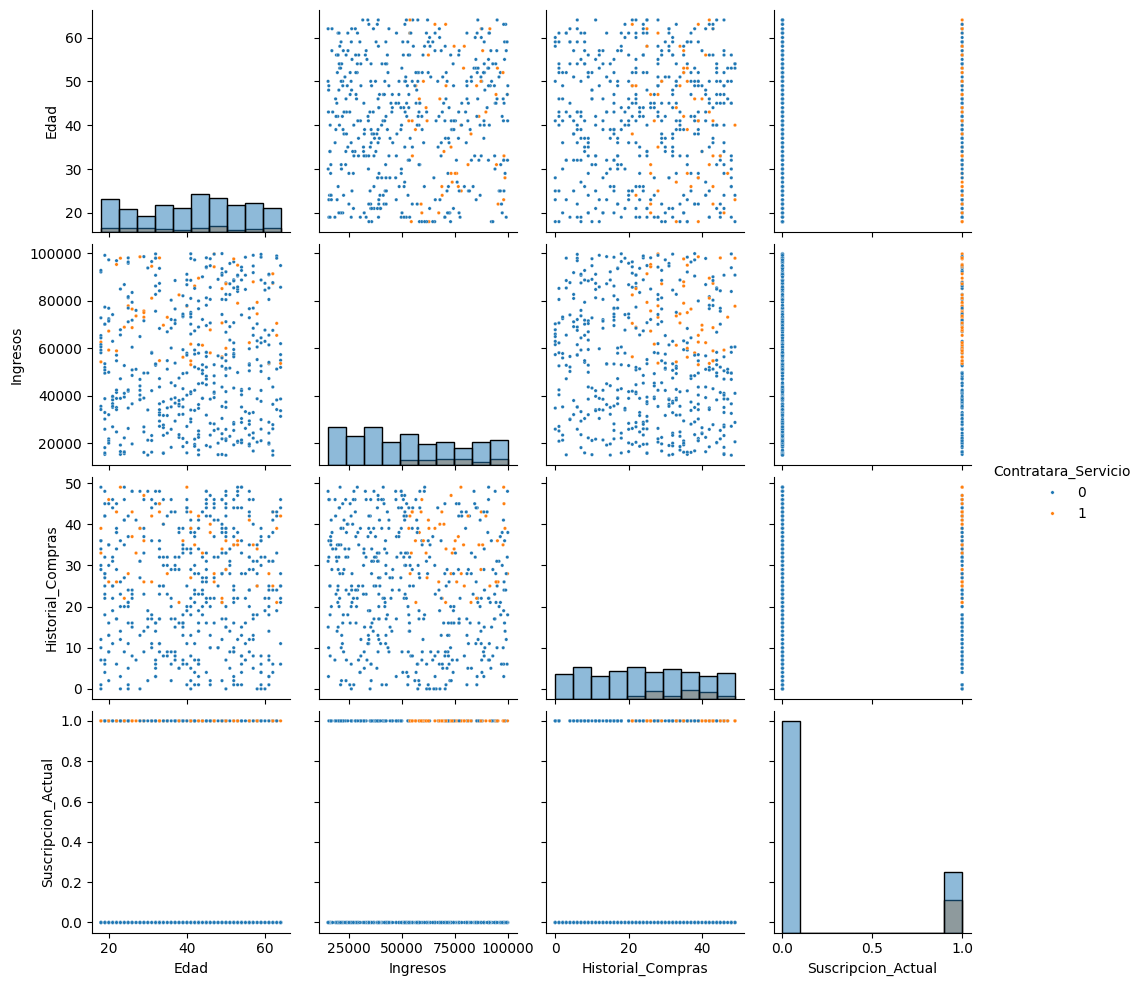

In [ ]:
sns.pairplot(df, diag_kind='hist', hue=target, plot_kws={'s':6})
plt.show()

- El 100% de los que no cuentan con suscripción actual no considera suscribirse al servicio.
- El 34.9% de los que cuentan con suscripción actual renovará el servico.
- El 65.1% de los que cuentan con suscripción actual no renovará el servicio.

In [ ]:
grouped = df.groupby('Suscripcion_Actual')['Contratara_Servicio']
grouped.value_counts(normalize=True)*100

Suscripcion_Actual  Contratara_Servicio
0                   0                      100.000000
1                   0                       65.131579
                    1                       34.868421
Name: proportion, dtype: float64

Aunque los modelos de clasificación clasificarán todos los registros, el enfoque principal para una predicción exitosa radica en identificar con precisión a los clientes que contratarán el servicio, que son un subconjunto de los 152 clientes con una suscripción actual. La evaluación de los modelos debe priorizar métricas que evalúen el rendimiento en esta clase minoritaria.

In [ ]:
total_registros_de_interes = grouped.value_counts()[grouped.value_counts().index.get_level_values(0) == 1].sum()
print(f'Total de registros de interés: {total_registros_de_interes}')

Total de registros de interés: 152


In [ ]:
# proporción de usuarios actualmente suscritos es de 30.4%
df['Suscripcion_Actual'].value_counts(normalize=True)*100

,proportion
Suscripcion_Actual,
0,69.6
1,30.4


In [ ]:
# proporción de usuarios que contratará el servicio es de 10.6%
df['Contratara_Servicio'].value_counts(normalize=True)*100

# las clases no están balanceadas, proporción de 9:1

,proportion
Contratara_Servicio,
0,89.4
1,10.6


##**Entrenamiento de modelos sin validación cruzada**

**2. Aplicación de modelos de clasificación (6 puntos)**

Implementa los siguientes modelos de clasificación y evalúa su desempeño:
- Regresión logística: Implementa el modelo y analiza cómo la función sigmoidea afecta la
clasificación.
- K-Nearest Neighbors (K-NN): Prueba distintos valores de k y analiza su impacto en la
exactitud.
- Árbol de decisión: Ajusta los hiperparámetros del modelo y analiza las medidas de impureza
de los nodos.
- Bosques aleatorios: Aplica bagging para mejorar la predicción y analiza la importancia de
las variables.
- Support Vector Machine (SVM): Experimenta con distintos tipos de kernel y compara los
resultados.  

Para cada modelo:
- Divide los datos en entrenamiento y prueba.
- Normaliza los datos si es necesario.
- Evalúa la precisión con métricas como accuracy.

In [ ]:
# función auxiliar

def matriz_de_confusion(y_test, y_pred):
    '''graficar la matriz de confusión'''

    plt.figure(figsize=(2,2))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

###**Generación de conjuntos de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[atributos], df[target], test_size=0.2, random_state=42)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (400, 4)
X_test shape: (100, 4)
y_train shape: (400,)
y_test shape: (100,)


- proporción de usuarios que contratará el servicio en el test set es de 10%
- proporción de usuarios que contratará el servicio en el test set es de 12%

- se mantiene la proporción aproximada de 9:1
- si no se hubiera mantenido, habría que haber incorporado el parámetro stratify=df[target] dentro del train_test_split

In [ ]:
y_train.value_counts()

,count
Contratara_Servicio,
0,359
1,41


In [ ]:
y_test.value_counts()

,count
Contratara_Servicio,
0,88
1,12


In [ ]:
# para registrar los puntajes de train y test sets para los diversos modelos
accuracy_sin_cv = dict() # puntajes sin validación cruzada

###**LogisticRegression**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(random_state=42))])

In [ ]:
y_pred_lr = pipe.predict(X_test)
accuracy_sin_cv['LogisticRegression'] = {'train':pipe.score(X_train, y_train), 'test':pipe.score(X_test, y_test)}

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        88
           1       0.75      1.00      0.86        12

    accuracy                           0.96       100
   macro avg       0.88      0.98      0.92       100
weighted avg       0.97      0.96      0.96       100



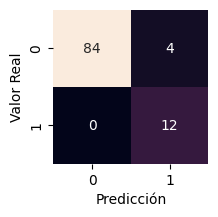

In [ ]:
matriz_de_confusion(y_test, y_pred_lr)

 Precision:
- De todas las veces que el modelo predijo "Clase 0", el 100% fueron correctas.  
-  De todas las veces que el modelo predijo "Clase 1", el 75% fueron correctas.  

Recall:
- De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 95%.
- De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 100%.

Accuracy es 96%.

Hay 4 falsos positivos. Veámoslos en un pairplot (en rojo los puntos mal clasificados).

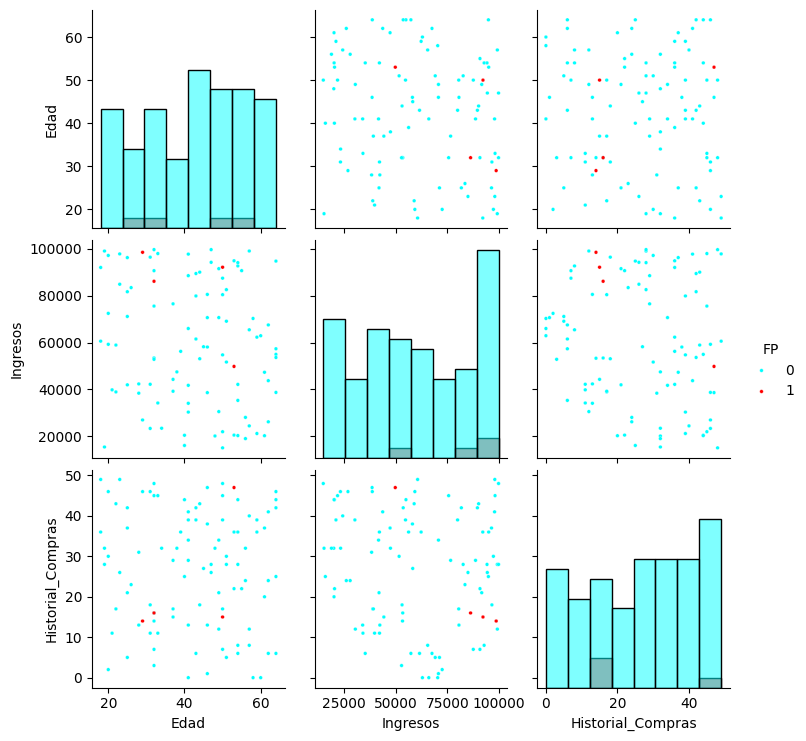

In [ ]:
dft = pd.concat([X_test.reset_index(drop=True), pd.Series(y_test.values), pd.Series(y_pred_lr)], axis=1)
dft.columns = atributos + [target, 'y_pred']
dft['FP'] = -(dft[target] - dft['y_pred'])
sns.pairplot(dft.drop(['Suscripcion_Actual', 'Contratara_Servicio', 'y_pred'], axis=1), diag_kind='hist', hue='FP', plot_kws={'s':7}, palette=['cyan','r'])
plt.show()

La función sigmoidea en Regresión Logística toma la combinación lineal de las características (z) y la transforma en una probabilidad entre 0 y 1 (σ(z)). Esta probabilidad se interpreta como la probabilidad de que un registro pertenezca a la clase positiva. Luego, se aplica un umbral (generalmente 0.5) para clasificar el registro en una de las dos clases (0 o 1). En este caso, el 96% de precisión indica que la función sigmoidea, basándose en la combinación lineal de las características escaladas, permitió al modelo clasificar correctamente la mayoría de los registros. Los falsos positivos ocurren cuando la probabilidad calculada por la sigmoidea supera el umbral, pero la clase real es la negativa, sugiriendo que una separación lineal perfecta no es posible.

###**KNeighborsClassifier**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [ ]:
y_pred_knn = pipe.predict(X_test)
accuracy_sin_cv['KNeighborsClassifier'] = {'train':pipe.score(X_train, y_train), 'test':pipe.score(X_test, y_test)}

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.92      1.00      0.96        12

    accuracy                           0.99       100
   macro avg       0.96      0.99      0.98       100
weighted avg       0.99      0.99      0.99       100



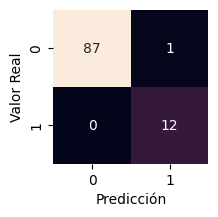

In [ ]:
matriz_de_confusion(y_test, y_pred_knn)

 Precision:
- De todas las veces que el modelo predijo "Clase 0", el 100% fueron correctas.  
-  De todas las veces que el modelo predijo "Clase 1", el 92% fueron correctas.  

Recall:
- De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 99%.
- De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 100%.

Accuracy es 99%.

Hay 1 falso positivo.

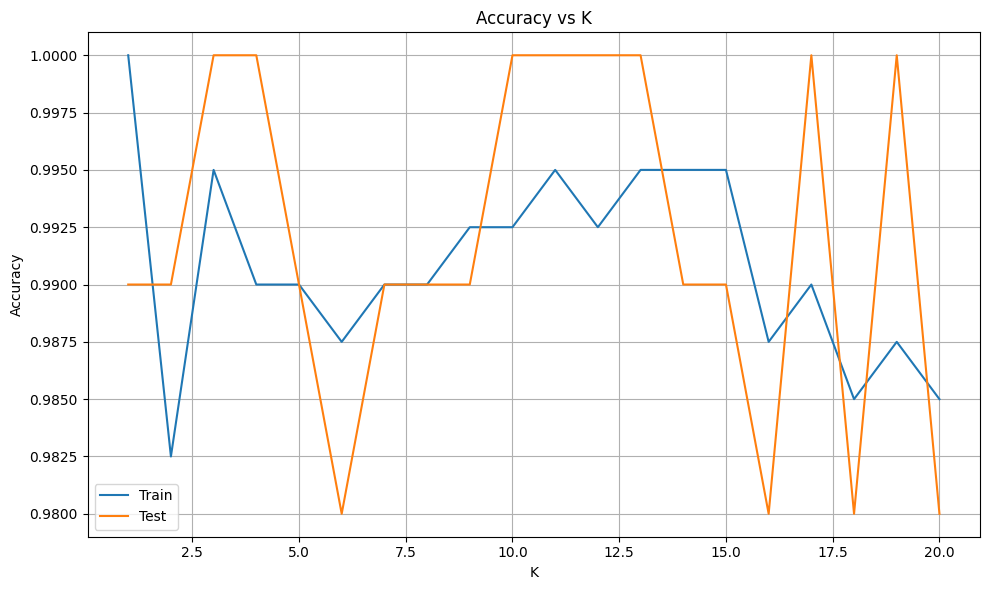

In [ ]:
# hagamos un gráfico de accuracy vs K

k_values = list(range(1, 21))
train_scores = []
test_scores = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Train')
plt.plot(k_values, test_scores, label='Test')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Basado en el gráfico de "Accuracy vs K":

- Precisión en el conjunto de entrenamiento: A medida que k aumenta, la precisión en el conjunto de entrenamiento tiende a disminuir o se mantiene alta con ligeras fluctuaciones. Con k=1, la precisión en el entrenamiento es del 100%, lo cual es esperado ya que cada punto se clasifica según su vecino más cercano (él mismo).
- Precisión en el conjunto de prueba: La precisión en el conjunto de prueba varía con k. Comienza alta para k=1 y alcanza el 100% para varios valores de k (como 3, 10, 11, 12, 13, 17, 18 y 19).
- Interpretación: Valores pequeños de k (como 1) pueden hacer que el modelo sea muy sensible al ruido en los datos de entrenamiento (alta varianza). A medida que k aumenta, el modelo considera más vecinos, suavizando el límite de decisión y potencialmente reduciendo la sensibilidad al ruido. En este caso, el modelo K-NN logra una precisión muy alta en el conjunto de prueba para un rango de valores de k.

###**DecisionTreeClassifier**

In [ ]:
# no requiere estandarización de atributos

modelo = DecisionTreeClassifier(max_depth=3, random_state=42)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_dt = modelo.predict(X_test)
accuracy_sin_cv['DecisionTreeClassifier'] = {'train':modelo.score(X_train, y_train), 'test':modelo.score(X_test, y_test)}

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00        12

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



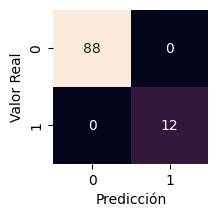

In [ ]:
matriz_de_confusion(y_test, y_pred_dt)

 Precision:
- De todas las veces que el modelo predijo "Clase 0", el 100% fueron correctas.  
-  De todas las veces que el modelo predijo "Clase 1", el 100% fueron correctas.  

Recall:
- De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 100%.
- De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 100%.

Accuracy es 100%.

Predicción perfecta.

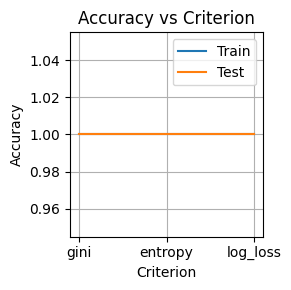

In [ ]:
# hagamos un gráfico de accuracy vs medidas de impureza

criterions = ['gini', 'entropy', 'log_loss']
train_scores = []
test_scores = []

for criterion in criterions:
    modelo = DecisionTreeClassifier(criterion=criterion, random_state=42, max_depth=3)
    modelo.fit(X_train, y_train)
    train_scores.append(modelo.score(X_train, y_train))
    test_scores.append(modelo.score(X_test, y_test))

plt.figure(figsize=(3,3))
plt.plot(criterions, train_scores, label='Train')
plt.plot(criterions, test_scores, label='Test')
plt.xlabel('Criterion')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Criterion')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Las medidas de impureza, como 'gini' (Gini impurity), 'entropy' (entropía) y 'log_loss' (pérdida logarítmica), son criterios utilizados por el algoritmo del Árbol de Decisión para evaluar la calidad de una división en un nodo. El objetivo es encontrar divisiones que reduzcan la impureza en los nodos hijos, creando nodos más "puros" donde la mayoría de las instancias pertenecen a una sola clase.

Observando el gráfico:

- Resultados: Tanto la precisión en el conjunto de entrenamiento como en el conjunto de prueba son del 100% para las tres medidas de impureza ('gini', 'entropy' y 'log_loss').
- Conclusión: Esto indica que, para el dataset y con la configuración de max_depth=3, el Árbol de Decisión puede lograr una separación perfecta de las clases en los datos de prueba, independientemente de si utiliza Gini, entropía o pérdida logarítmica como criterio para las divisiones.

###**RandomForestClassifier**

In [ ]:
# no requiere estandarización de atributos

modelo = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)

modelo.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_rf = modelo.predict(X_test)
accuracy_sin_cv['RandomForestClassifier'] = {'train':modelo.score(X_train, y_train), 'test':modelo.score(X_test, y_test)}

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00        12

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



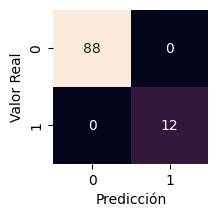

In [ ]:
matriz_de_confusion(y_test, y_pred_rf)

 Precision:
- De todas las veces que el modelo predijo "Clase 0", el 100% fueron correctas.  
-  De todas las veces que el modelo predijo "Clase 1", el 100% fueron correctas.  

Recall:
- De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 100%.
- De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 100%.

Accuracy es 100%.

Predicción perfecta.

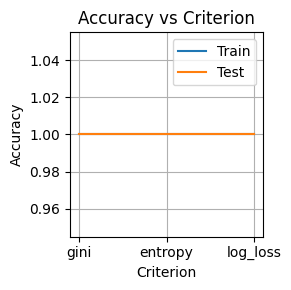

In [ ]:
# hagamos un gráfico de accuracy vs medidas de impureza

criterions = ['gini', 'entropy', 'log_loss']
train_scores = []
test_scores = []

for criterion in criterions:
    modelo = RandomForestClassifier(criterion=criterion, random_state=42, max_depth=3)
    modelo.fit(X_train, y_train)
    train_scores.append(modelo.score(X_train, y_train))
    test_scores.append(modelo.score(X_test, y_test))

plt.figure(figsize=(3,3))
plt.plot(criterions, train_scores, label='Train')
plt.plot(criterions, test_scores, label='Test')
plt.xlabel('Criterion')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Criterion')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Similar a los Árboles de Decisión individuales, los Bosques Aleatorios utilizan medidas de impureza (como 'gini', 'entropy' y 'log_loss') para decidir las mejores divisiones en cada uno de los árboles que componen el bosque. Cada árbol en el bosque se construye tratando de reducir la impureza en sus nodos.

Observando el gráfico para el Bosque Aleatorio:

- Resultados: Al igual que con el Árbol de Decisión individual en tu análisis anterior, tanto la precisión en el conjunto de entrenamiento como en el conjunto de prueba son del 100% para las tres medidas de impureza ('gini', 'entropy' y 'log_loss').
- Conclusión: Esto demuestra que, para el dataset y con la configuración de max_depth=3  el Bosque Aleatorio también puede lograr una separación perfecta de las clases en los datos de prueba, independientemente del criterio de impureza utilizado por los árboles individuales.  

Dado que los Árboles de Decisión individuales ya pudieron lograr una precisión perfecta en este dataset (con ciertas configuraciones de profundidad), no es sorprendente que un conjunto de estos árboles (Random Forest) también lo logre, y que la elección del criterio de impureza no marque una diferencia en este escenario de precisión perfecta. En datasets más complejos donde los árboles individuales podrían tener dificultades, el criterio de impureza y el efecto de Bagging en Random Forest podrían mostrar diferencias más notables. Sin embargo, aquí, la tarea de clasificación parece ser relativamente sencilla para estos modelos.

###**SVC**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', random_state=42))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(kernel='linear', random_state=42))])

In [ ]:
y_pred_svc = pipe.predict(X_test)
accuracy_sin_cv['SVC'] = {'train':pipe.score(X_train, y_train), 'test':pipe.score(X_test, y_test)}

In [ ]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        88
           1       0.75      1.00      0.86        12

    accuracy                           0.96       100
   macro avg       0.88      0.98      0.92       100
weighted avg       0.97      0.96      0.96       100



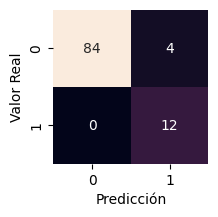

In [ ]:
matriz_de_confusion(y_test, y_pred_svc)

 Precision:
- De todas las veces que el modelo predijo "Clase 0", el 100% fueron correctas.  
-  De todas las veces que el modelo predijo "Clase 1", el 75% fueron correctas.  

Recall:
- De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 95%.
- De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 100%.

Accuracy es 96%.

Hay 4 falsos positivos.

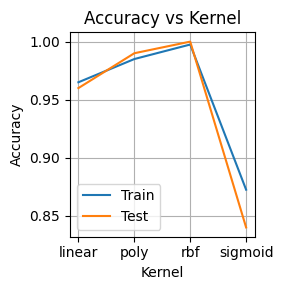

In [ ]:
# hagamos un gráfico de accuracy vs kernel

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
train_scores = []
test_scores = []

for kernel in kernels:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel=kernel, random_state=42))
    ])

    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(3,3))
plt.plot(kernels, train_scores, label='Train')
plt.plot(kernels, test_scores, label='Test')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Kernel')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

El kernel en un modelo SVM determina cómo se transforma el espacio de características y, por lo tanto, la forma del límite de decisión que el modelo puede encontrar. Diferentes kernels permiten al SVM encontrar relaciones lineales o no lineales en los datos.

Observando el gráfico:

- Resultados:
    - 'linear' kernel: Muestra una precisión de entrenamiento y prueba de alrededor del 96%. Esto sugiere que un límite de decisión lineal puede clasificar la mayoría de los puntos, pero no todos.
    - 'poly' kernel: La precisión de entrenamiento y prueba aumenta ligeramente en comparación con el kernel lineal, acercándose al 98%. Esto indica que un límite de decisión polinómico puede capturar mejor algunas de las relaciones en los datos.
    - 'rbf' kernel: Este kernel logra una precisión de entrenamiento y prueba del 100%. El kernel RBF (Radial Basis Function) es muy flexible y puede crear límites de decisión complejos y no lineales. En este caso, parece que el kernel RBF es capaz de encontrar un límite que separa perfectamente las clases en el conjunto de datos.
    - 'sigmoid' kernel: La precisión de entrenamiento y prueba disminuye significativamente con el kernel sigmoide, cayendo a alrededor del 87%. Este kernel a menudo se comporta de manera similar a una red neuronal de una sola capa y puede no ser adecuado para todos los tipos de datos.

- Conclusión: El gráfico demuestra claramente el impacto del tipo de kernel en el rendimiento del modelo SVC. El kernel 'linear' muestra que una separación lineal no es suficiente para una clasificación perfecta. Los kernels 'poly' y especialmente 'rbf' mejoran la precisión al permitir límites de decisión no lineales. El kernel 'rbf' destaca como el más adecuado para este dataset, logrando una precisión perfecta. El bajo rendimiento del kernel 'sigmoid' sugiere que no es una buena opción para capturar los patrones en tus datos.  

Este análisis resalta la importancia de seleccionar un kernel apropiado para el modelo SVM, ya que la elección correcta puede mejorar drásticamente su capacidad para clasificar los datos.

###**Resumen para modelos sin validación cruzada**

In [ ]:
pd.DataFrame(accuracy_sin_cv).T.sort_values(by=['test','train'], ascending=False)

,train,test
DecisionTreeClassifier,1.0000,1.00
RandomForestClassifier,1.0000,1.00
KNeighborsClassifier,0.9900,0.99
LogisticRegression,0.9675,0.96
SVC,0.9650,0.96


Modelos que obtuvieron clasificación perfecta tanto en train como en test sets:
- Decision Tree,
- Random Forest.

Modelo con peor desempeño:
- Support Vector Machine

De acuerdo a los resultados obtenidos, ningún modelo parece ni sobre ni subajustado.

##**Ajuste de Hiperparámetros con validación cruzada**

In [ ]:
# para registrar los puntajes de oof y test sets para los diversos modelos con validación cruzada
accuracy_con_cv = dict()

# configurar los folders de modo que se mantenga la proporción de clases
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

###**LogisticRegression**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

param_grid={
    'model__C'           : [0.01, 0.1, 1, 10, 100],   # 1 por defecto
    'model__class_weight': [None, 'balanced'],        # None por defecto
    'model__solver'      : ['liblinear', 'lbfgs']     # lbfgs por defecto
}

gs = GridSearchCV(pipe, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__solver': ['liblinear', 'lbfgs']})

Mejores parámetros encontrados:
 {'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}



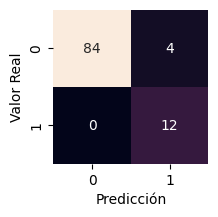

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}\n')

y_pred_lr_gs = gs.predict(X_test)
accuracy_con_cv['LogisticRegression'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_lr_gs)

Se mantienen 4 falsos positivos.

###**KNeighborsClassifier**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid={
    'model__n_neighbors': [3, 5, 7, 9, 11],          # 5 por defecto
    'model__weights'    : ['uniform', 'distance']    # uniform por defecto
}

gs = GridSearchCV(pipe, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             param_grid={'model__n_neighbors': [3, 5, 7, 9, 11],
                         'model__weights': ['uniform', 'distance']})

Mejores parámetros encontrados:
 {'model__n_neighbors': 11, 'model__weights': 'uniform'}



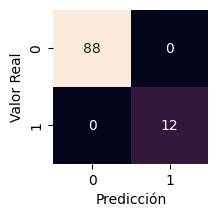

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}\n')

y_pred_knn_gs = gs.predict(X_test)
accuracy_con_cv['KNeighborsClassifier'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_knn_gs)

Ahora se obtiene una predicción perfecta.

###**DecisionTreeClassifier**

In [ ]:
# no requiere estandarización de atributos

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_train, y_train)

param_grid={
    'max_depth': [None, 3, 5, 7, 9, 11],   # None por defecto
    'min_samples_split': [2, 5, 10],       # 2 por defecto
    'min_samples_leaf': [1, 2, 4],         # 1 por defecto
    'criterion': ['gini', 'entropy'],      # gini por defecto
    'class_weight': [None, 'balanced'],    # None por defecto
    #'max_features': [None, 'sqrt', 'log2'] # None por defecto
}

gs = GridSearchCV(modelo, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 9, 11],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

Mejores parámetros encontrados:
 {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}



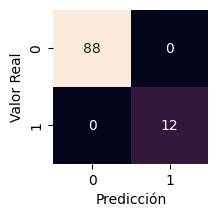

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}\n')

y_pred_dt_gs = gs.predict(X_test)
accuracy_con_cv['DecisionTreeClassifier'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_dt_gs)

Se mantiene la predicción perfecta.

In [ ]:
# bagging al árbol de decisión

modelo = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42, n_estimators=10)

param_grid={
    'estimator__max_depth': [None, 3, 5, 7, 9, 11],   # None por defecto
    'estimator__min_samples_split': [2, 5, 10],       # 2 por defecto
    'estimator__min_samples_leaf': [1, 2, 4],         # 1 por defecto
    'estimator__criterion': ['gini', 'entropy'],      # gini por defecto
    'estimator__class_weight': [None, 'balanced'],    # None por defecto
    #'estimator__max_features': [None, 'sqrt', 'log2'] # None por defecto
}

gs = GridSearchCV(modelo, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                         random_state=42),
             param_grid={'estimator__class_weight': [None, 'balanced'],
                         'estimator__criterion': ['gini', 'entropy'],
                         'estimator__max_depth': [None, 3, 5, 7, 9, 11],
                         'estimator__min_samples_leaf': [1, 2, 4],
                         'estimator__min_samples_split': [2, 5, 10]})

Mejores parámetros encontrados:
 {'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}



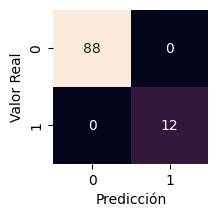

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}\n')

y_pred_dt_bg_gs = gs.predict(X_test)
#accuracy_con_cv['DecisionTreeClassifier_bg'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_dt_bg_gs)

Se mantiene la predicción perfecta.

###**RandomForestClassifier**

In [ ]:
# no requiere estandarización de atributos

modelo = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)

param_grid={
    'n_estimators': [10, 50],                # 100 por defecto
    'max_depth': [None, 3, 5],               # None por defecto
    'min_samples_split': [2, 5, 10],              # 2 por defecto
    'min_samples_leaf': [1, 2, 4],                # 1 por defecto
    #'max_features': [None 'sqrt', 'log2'],     # None por defecto
    'class_weight': [None, 'balanced']            # None por defecto
}

gs = GridSearchCV(modelo, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(max_depth=3, random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 3, 5],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50]})

Mejores parámetros encontrados:
 {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}



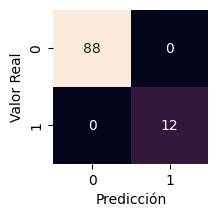

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}\n')

y_pred_rf_gs = gs.predict(X_test)
accuracy_con_cv['RandomForestClassifier'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_rf_gs)

Se mantiene la predicción perfecta.

###**SVC**

In [ ]:
# requiere estandarización de atributos

pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])

param_grid={
    'model__kernel'      : ['linear', 'poly', 'rbf', 'sigmoid'],   # rbf por defecto
    'model__class_weight': [None, 'balanced'],                     # None por defecto
    'model__C'           : [0.01, 0.1, 1, 10, 100]                 # 1 por defecto
}

gs = GridSearchCV(pipe, param_grid=param_grid, cv=skf)
gs.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVC(random_state=42))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': [None, 'balanced'],
                         'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

Mejores parámetros encontrados:
 {'model__C': 1, 'model__class_weight': None, 'model__kernel': 'rbf'}


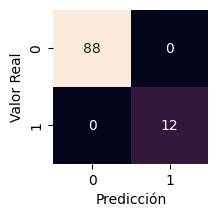

In [ ]:
print(f'Mejores parámetros encontrados:\n {gs.best_params_}')

y_pred_svc_gs = gs.predict(X_test)
accuracy_con_cv['SVC'] = {'oof':gs.best_score_, 'test':gs.score(X_test, y_test)}

matriz_de_confusion(y_test, y_pred_svc_gs)

Ahora se obtiene una predicción perfecta.

###**Resumen para modelos con validación cruzada**

In [ ]:
pd.DataFrame(accuracy_con_cv).T.sort_values(by=['test','oof'], ascending=False)

,oof,test
DecisionTreeClassifier,0.9975,1.00
RandomForestClassifier,0.9975,1.00
SVC,0.9925,1.00
KNeighborsClassifier,0.9900,1.00
LogisticRegression,0.9675,0.96


Modelos que obtuvieron clasificación perfecta en el test set:
- Decision Tree,
- Random Forest,
- SVC,
- KNeighborsClassifier.

Decision Tree y Random Forest tienen la misma accuracy oof (0.9975), en tanto que la de SVC es apenas menor (0.9925).

Modelo con peor desempeño tanto en las predicciones oof y la del test set:
- Logistic Regression (oof: 0.9675, test: 0.96).

De acuerdo a los resultados obtenidos, ningún modelo parece ni sobre ni subajustado de manera significativa, ya que los puntajes de OOF y test son cercanos y varios modelos lograron alta precisión.

**3. Análisis de resultados (3 puntos)**
- Comparación de modelos: Explica cuál modelo tuvo mejor desempeño y por qué.
- Impacto de los hiperparámetros: Describe cómo afectaron los hiperparámetros en cada
modelo.
- Aplicabilidad: Indica en qué casos sería recomendable utilizar cada algoritmo.

In [ ]:
accuracies = pd.merge(pd.DataFrame(accuracy_sin_cv).T, pd.DataFrame(accuracy_con_cv).T, left_index=True, right_index=True, how='inner')
accuracies.columns = ['train_sin_cv', 'test_sin_cv', 'oof_con_cv', 'test_con_cv']
accuracies.sort_values(by=['test_con_cv','oof_con_cv'], ascending=False)

,train_sin_cv,test_sin_cv,oof_con_cv,test_con_cv
DecisionTreeClassifier,1.0000,1.00,0.9975,1.00
RandomForestClassifier,1.0000,1.00,0.9975,1.00
SVC,0.9650,0.96,0.9925,1.00
KNeighborsClassifier,0.9900,0.99,0.9900,1.00
LogisticRegression,0.9675,0.96,0.9675,0.96


Resumen Adicional del Análisis de Accuracies:

El análisis de la tabla accuracies (que compara los resultados antes y después de la validación cruzada con ajuste de hiperparámetros) aporta lo siguiente:

1. Impacto del Ajuste de Hiperparámetros y Validación Cruzada:
    - Para la Regresión Logística, el ajuste no produjo cambios significativos, manteniendo puntuaciones similares.
    - Para KNeighborsClassifier, la precisión en prueba mejoró ligeramente de 0.99 a 1.00 con el ajuste.
    - Para Árbol de Decisión y Bosque Aleatorio, que ya tenían precisión perfecta inicialmente, la validación cruzada confirmó este rendimiento y mostró puntuaciones OOF muy altas, indicando robustez.
    - Para SVC, el ajuste fue muy efectivo, mejorando drásticamente la precisión en prueba de 0.96 a 1.00 y la puntuación OOF a 0.9925, demostrando la importancia de encontrar el kernel adecuado ('rbf' en este caso).

2. Consistencia de la Evaluación: Los puntajes de prueba después de la validación cruzada son consistentes o mejores que los iniciales, lo que sugiere que la división inicial fue representativa y que la validación cruzada proporciona estimaciones fiables. Las puntuaciones OOF ofrecen una visión más robusta del rendimiento generalizado.

3. Identificación de los Mejores Modelos: Aunque varios modelos lograron precisión perfecta en prueba después del ajuste, las puntuaciones OOF (Decision Tree y Random Forest con 0.9975, seguidos por SVC con 0.9925 y K-NN con 0.9900) sugieren que el Árbol de Decisión y el Bosque Aleatorio fueron ligeramente más consistentes en su alto rendimiento a través de los diferentes folds de la validación cruzada.


En resumen, el análisis comparativo muestra cómo el ajuste de hiperparámetros puede mejorar significativamente el rendimiento de modelos como SVC y confirma la alta capacidad de clasificación de los modelos basados en árboles y K-NN en este dataset. Las puntuaciones OOF son clave para entender la consistencia del rendimiento.

**Aplicabilidad de cada Algoritmo de Clasificación:**

Considerando las características intrínsecas de cada algoritmo de clasificación y los resultados obtenidos en este análisis particular, se pueden establecer las siguientes recomendaciones sobre su aplicabilidad:

1. Regresión Logística:
     -Cuándo usar: Este algoritmo es un punto de partida sólido y eficiente para problemas de clasificación binaria, especialmente cuando se busca interpretabilidad de las probabilidades y los datos presentan una relación aproximadamente lineal entre las características y la probabilidad de la clase positiva. Es menos adecuado si la relación es marcadamente no lineal.
    - Observación del análisis: En nuestro caso, no logró la precisión perfecta, lo que sugiere que la separabilidad lineal no es completa, aunque su rendimiento inicial (96%) fue aceptable.
2. K-Nearest Neighbors (K-NN):
    - Cuándo usar: Recomendado para datasets donde la frontera de decisión es compleja o irregular y las instancias de una misma clase tienden a agruparse en el espacio de características. Es simple y no paramétrico, pero requiere escalado de características y puede ser costoso computacionalmente en grandes volúmenes de datos o alta dimensionalidad durante la predicción.
    - Observación del análisis: Demostró un rendimiento muy alto, alcanzando la precisión perfecta tras el ajuste, lo que indica que la proximidad en el espacio de características es un fuerte predictor en este dataset.
3. Árbol de Decisión (Decision Tree):
    - Cuándo usar: Útil por su facilidad de comprensión, visualización e interpretabilidad. Puede capturar relaciones no lineales e interacciones entre características. Es ideal cuando se necesita entender el proceso de toma de decisiones basado en reglas. Sin embargo, un solo árbol puede ser propenso al sobreajuste si no se controla su profundidad.
    - Observación del análisis: Logró precisión perfecta, lo que sugiere la existencia de reglas jerárquicas claras en los datos para la clasificación. A pesar de ello, en datasets más complejos o ruidosos, se preferiría un enfoque de conjunto para mitigar el sobreajuste.
4. Bosques Aleatorios (Random Forest):
    - Cuándo usar: Es un algoritmo de conjunto muy robusto y de alto rendimiento, adecuado para una amplia gama de tareas de clasificación. Mitiga el sobreajuste de los árboles individuales mediante Bagging y la aleatoriedad en la selección de características. Puede manejar relaciones no lineales, interacciones y proporciona métricas de importancia de características. Es a menudo un modelo de referencia.
    - Observación del análisis: Al igual que el Árbol de Decisión, obtuvo precisión perfecta, manteniendo la alta capacidad predictiva mientras ofrece mayor robustez potencial.
5. Support Vector Machine (SVC):
    - Cuándo usar: Poderoso para encontrar fronteras de decisión óptimas, especialmente en espacios de alta dimensión. La elección adecuada del kernel permite modelar relaciones tanto lineales como no lineales complejas.
    - Observación del análisis: Su rendimiento mejoró drásticamente al pasar de un kernel lineal al 'rbf' durante el ajuste de hiperparámetros, alcanzando la precisión perfecta. Esto subraya su capacidad para encontrar límites de decisión no lineales efectivos cuando existen.
    
En conclusión:

La elección del algoritmo más adecuado depende de las características específicas del dataset y los objetivos del proyecto. En este caso particular, donde parece existir una frontera de decisión no lineal pero clara y separable, modelos no lineales como K-NN, Árboles de Decisión, Bosques Aleatorios y SVC (con kernel 'rbf') demostraron una capacidad superior para lograr una clasificación perfecta en comparación con un modelo lineal como la Regresión Logística. Para datasets más complejos o con más ruido, los modelos de conjunto como Random Forest o SVC con kernels no lineales suelen ofrecer la mejor combinación de rendimiento y robustez.